# Supplementary figures — copied from `../coloc_plots.ipynb`

**This is a near-verbatim copy of the source notebook**, not a cleaned
reproduction. Only inert cells were removed: empty cells, cells that are
entirely commented out, and cells that only `print()` or display a table.

Panels produced here: `sup_hyperthyroid_exp`, `sup_hyperthyroid_sp` — the two
supplementary panels that exist **only** in this notebook and not in
`../Supplementary_coloc_examples.ipynb`.

`coloc_plots.ipynb` is also the source of several main Figure 4 panels, which
are reproduced properly in `../Figure4/`. Those cells are still present here;
their `savefig` calls now write into this directory's `plots/`, so running this
notebook will not touch the published Figure 4 files.

Two mechanical path edits were applied so the notebook runs from this directory
and cannot overwrite the published figures:

* `../code/...` → `../../code/...` (this notebook sits one level deeper)
* `../code/plots/` → `plots/` and `../code/revision_plots/` → `revision_plots/`

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tabix
import gzip
import vcf

In [2]:

def plot_isoform_annotations(annotation_exons, gene, colores=None, start=None, end=None, 
                             figsize=None, lwidth=5, iso_order=None, axes=None, xlim=None):

    gene_exons = annotation_exons.loc[annotation_exons.gene_id == gene]

    if iso_order is None:
        isoforms = sorted(gene_exons.transcript_id.unique())
    else:
        isoforms = iso_order

    isoform_dict = {}
    for i, iso in enumerate(isoforms):
        isoform_name = f'isoform_{str(i+1)}'
        df = gene_exons.loc[gene_exons.transcript_id == iso].copy()
        df['transcript_id'] =  f'{gene}.{isoform_name}'
        isoform_dict.update({isoform_name:{'df':df}})

    try:
        chrom = list(annotation_exons.chrom)[0]
    except:
        chrom = list(annotation_exons['#chrom'])[0]
    if start is None:
        start = str(np.min([int(list(gene_exons.start)[0]), int(list(gene_exons.start)[0])]) - 1000)
    if end is None:
        end = str(np.max([int(list(gene_exons.end)[-1]), int(list(gene_exons.end)[-1])]) + 1000)

    coords = [f'{chrom}:{start}', f'{chrom}:{end}']

    # print(isoform_dict)

    plot_gene_isoforms(isoform_dict, coords, color_list = colores, figsize=figsize, lwidth=lwidth, axes=axes, xlim=xlim)


def plot_gene_isoforms(isoforms_dict, coordinates, color_list = None, axes=None, figsize=None, lwidth=5, xlim=None):


    if xlim is None:
        xlim1 = int(coordinates[0].split(':')[1])
        xlim2 = int(coordinates[-1].split(':')[1])
#         print(xlim)
    else:
        xlim1 = xlim[0]
        xlim2 = xlim[1]
    

    if color_list is None:
        color_list = sns.color_palette("tab10")

    K = len(isoforms_dict)

    if figsize is None:
        figsize=(20, 3)

    if axes is None:
        fig, axes = plt.subplots(K, 1, figsize=figsize)

    for i in range(K):
        isoform_df = isoforms_dict[f'isoform_{str(i+1)}']['df']
        # print(isoform_df)
        ax = axes[i]
        color = color_list[i]
        plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth=lwidth)


def plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth):
    # print(isoform_df)
    is_first = True
    for idx, row in isoform_df.iterrows():
        start = int(row.start)
        end = int(row.end)
        if is_first:
            first = end
            is_first = False
    
        ax.fill_between([start, end], [0, 0], [1, 1], color = color, zorder=2)
    
    ax.plot([first, start], [0.5, 0.5], c=color, linewidth=lwidth)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['bottom', 'top', 'right', 'left']].set_visible(False)
    ax.set_xlim([xlim1, xlim2])

    # print(xlim1, xlim2)


In [3]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr11.txt.tabix.gz')

# Define a function to read the content
def run_tabix(tabix_file, chrom, start, end, file_type = 'other'):
    tabix_obj = tabix.open(tabix_file)
    # Fetch data from the tabix file in the desired range
    result = tabix_obj.query(chrom, start, end)
    
    rows = [line for line in result]
    
    with gzip.open(tabix_file) as fh:
        cols = fh.readline().decode().rstrip().split('\t')
    
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    if file_type == 'leafcutter':
        df['gid'] = df.pid.apply(lambda x: x.split(':')[3])
    elif file_type == 'expression':
        df['gid'] = df.pid.apply(lambda x: x.split('.')[0])
        
    return df


In [4]:
nom_df = pd.read_csv('../../code/results/coloc/hyprcoloc_results/tables/up_results.tsv.gz', sep='\t')

In [5]:
best_df = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'UP') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta <= -0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta >= 0.01)))]
best_df2 = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'PR') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta >= 0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta <= -0.01)))]
best_df.loc[best_df.gene == 'ENSG00000100412']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,0.000005,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [6]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

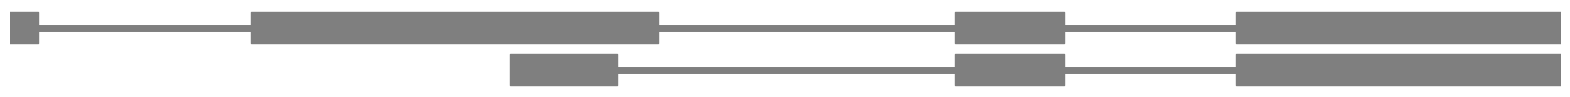

In [7]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000528122', 'ENST00000411829'])], 'ENSG00000177595', 
                         colores=['tab:gray']*3, start=802376-300, end=802542+300, figsize=(20, 1), lwidth=5, iso_order=None)

In [8]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['#Chr'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])

In [9]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['#phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]
snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))

In [10]:
LD = pd.read_csv('../../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)


In [11]:
gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

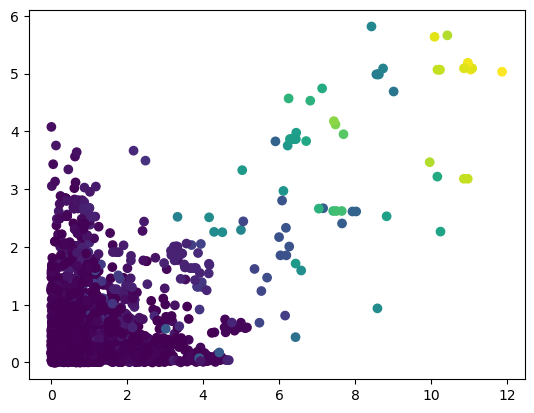

In [12]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
plt.scatter(x, y, c=r2)

In [13]:
def get_best_snp_record(vcf, snp):
    
    chrom, location = snp.split(':')
    location = int(location)
    
    record_list = []
    for record in vcf.fetch(chrom, location-1, location+1):  
        if record.POS == location:
#             print(chrom, location)
            return [record]
        record_list.append(record)
        
    return record_list


In [14]:
vcf_gtex = vcf.Reader(open("/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz", 'br'))

In [15]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

In [16]:
for r in records:
    break

In [17]:
   
def make_boxplot_df(qqnorm_data, phenotype, record, phenotype_class='',
                    color_by_phenotype=False, color='black'):
    # `color` follows the Fig. 4e convention: tab:red for unproductive
    # splicing, tab:blue for expression. Box faces stay white and the
    # median stays black; the colour is carried by outlines and points.
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    if color_by_phenotype:
        colores = [color_by_phenotype]*3

    else:
        colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.5, fliersize=0, 
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor=color),
                whiskerprops=dict(color=color), capprops=dict(color=color),
                medianprops=dict(linewidth=2, color='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.9, edgecolor=color,
                  facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    # n per genotype, under each tick -- same convention as Fig. 4e
    counts = df.genotype.value_counts()
    order = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{g}\nn={counts[g]}' for g in order])

    return ax


QTL_DIR = '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/qtls'


def nominal_qtl_stats(tissue, kind, phenotype, snp):
    """Nominal-pass beta and P for one phenotype-variant pair.

    `kind` is 'leafcutter' or 'expression'; `snp` is 'chr11:611503'. Returns
    (beta, pval), or (None, None) when the pair was not tested.

    These are the NOMINAL statistics for the exact variant on the x axis, not
    the phenotype-level permutation-pass values, so the annotation describes the
    genotypes actually plotted.
    """
    chrom, pos = snp.split(':')
    pos = int(pos)
    f = f'{QTL_DIR}/{tissue}/{kind}.NominalPass/{chrom}.txt.tabix.gz'
    with gzip.open(f) as fh:
        cols = fh.readline().decode().rstrip().split('\t')
    for row in tabix.open(f).query(chrom, pos - 1, pos + 1):
        d = dict(zip(cols, row))
        if d['#phe_id'] == phenotype and int(d['var_from']) == pos:
            return float(d['slope']), float(d['nom_pval'])
    return None, None


def fmt_qtl(beta, pval):
    """beta / P annotation, in the Fig. 4e format."""
    if beta is None:
        return ''
    exp = int(f'{pval:e}'.split('e')[1])
    mant = pval / (10 ** exp)
    return r'$\beta = ' + f'{beta:.2f}' + r'$' + '\n' + f'P = {mant:.1f}' + r'$\times 10^{' + str(exp) + r'}$'


In [18]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

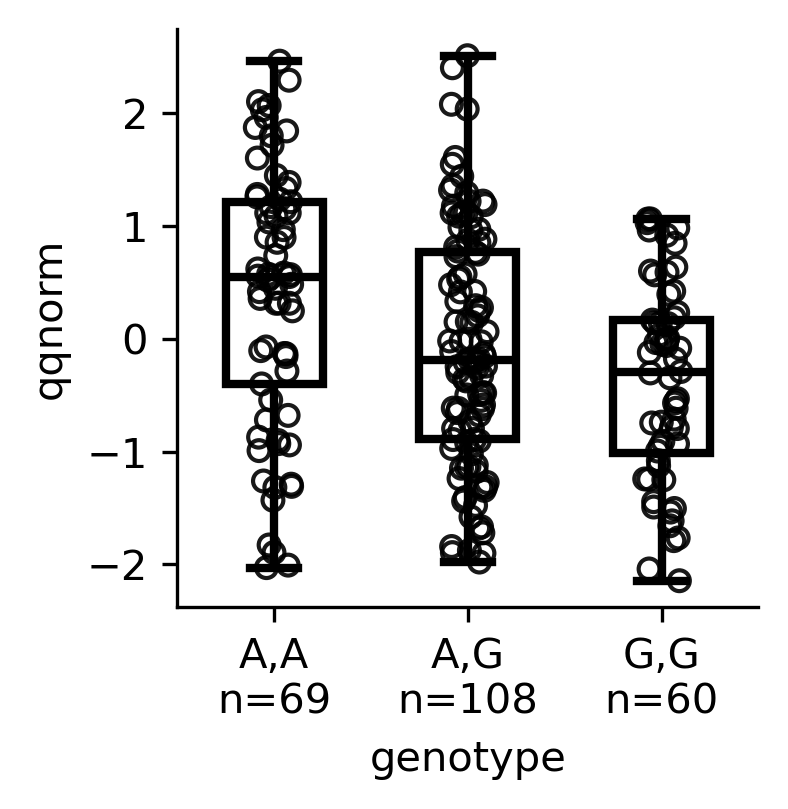

In [19]:
df = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', records[0])
# ax.set_xlabel('rs7941547')
# ax.set_ylabel('normalized splicing\nThyroid')

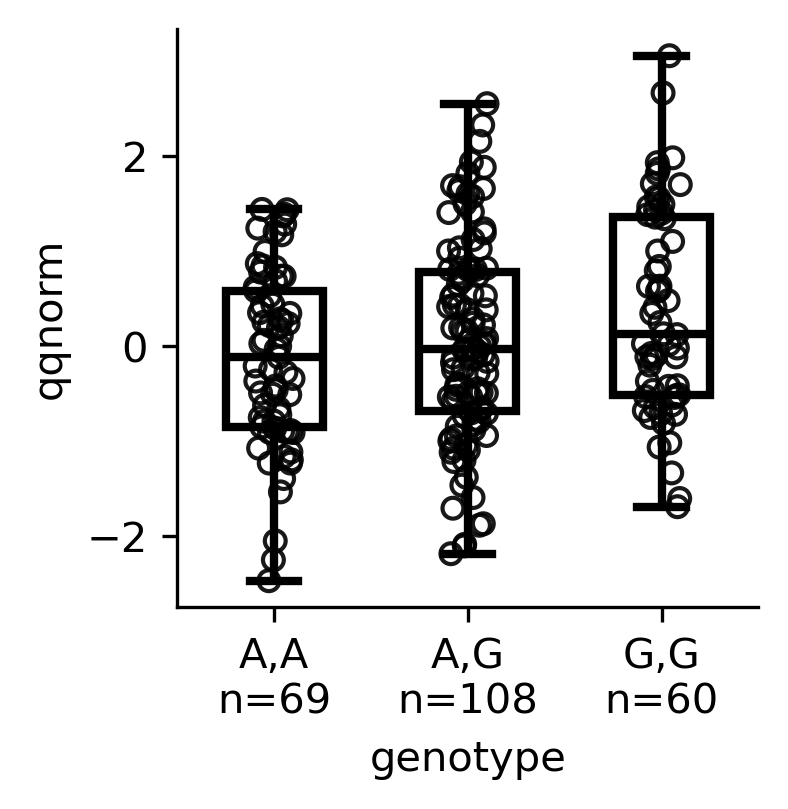

In [20]:
df = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])

In [21]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-30000, 614475+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_sp = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_sp_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

# 1

In [22]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Hypothyroidism.standardized.txt.tabix.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../../code/resources/gwas/hg38_summary_stats/Hypothyroidism.bed.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Thyroid/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Thyroid/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_sp = run_tabix('../../code/results/coloc/qtls/Spleen/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp['snp_pos'] = nom_sp.var_chr + ':' + nom_sp.var_from


nom_sp_e = run_tabix('../../code/results/coloc/qtls/Spleen/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp_e['snp_pos'] = nom_sp_e.var_chr + ':' + nom_sp_e.var_from

nom_sp['gwas_trait'] = nom_sp['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_sp_e['gwas_trait'] = nom_sp_e['#phe_id'].apply(lambda x: x.split(':')[-1])








In [23]:
nom = nom.loc[(nom.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom['#phe_id'] == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb['#phe_id'] == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl['#phe_id'] == 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_sp = nom_sp.loc[(nom_sp.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp['#phe_id'] == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_sp_e = nom_sp_e.loc[(nom_sp_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos)).intersection(pd.Index(nom_wb_e.snp_pos)).intersection(pd.Index(nom_wb.snp_pos)).intersection(pd.Index(nom_sp_e.snp_pos)).intersection(pd.Index(nom_sp.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

nom_wb = nom_wb.groupby('snp_pos').first()
nom_wb_e = nom_wb_e.groupby('snp_pos').first()

nom_sp = nom_sp.groupby('snp_pos').first()
nom_sp_e = nom_sp_e.groupby('snp_pos').first()

In [24]:
LD = pd.read_csv('../../code/results/coloc/LD/chr11_578759_N_N_Hypothyroidism.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



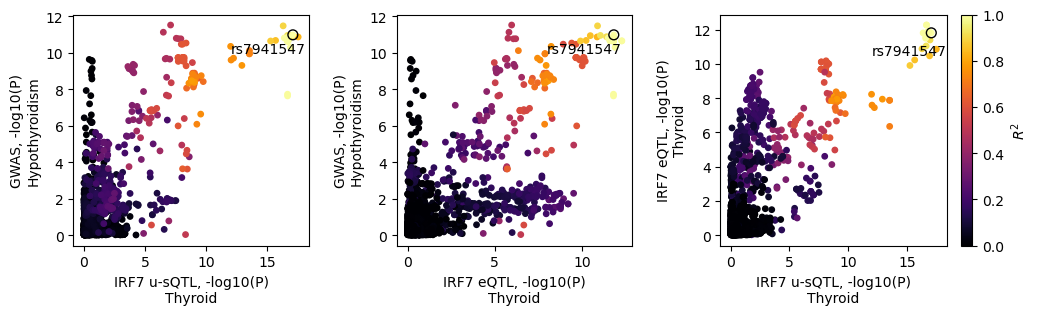

In [25]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(12, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nThyroid')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(8, 10, 'rs7941547')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nThyroid')

x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(12, 10.5, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

plt.savefig('plots/sup_hyperthyroid.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid.svg', dpi=300, bbox_inches='tight') 

In [26]:
qqnorm.index = qqnorm.pid

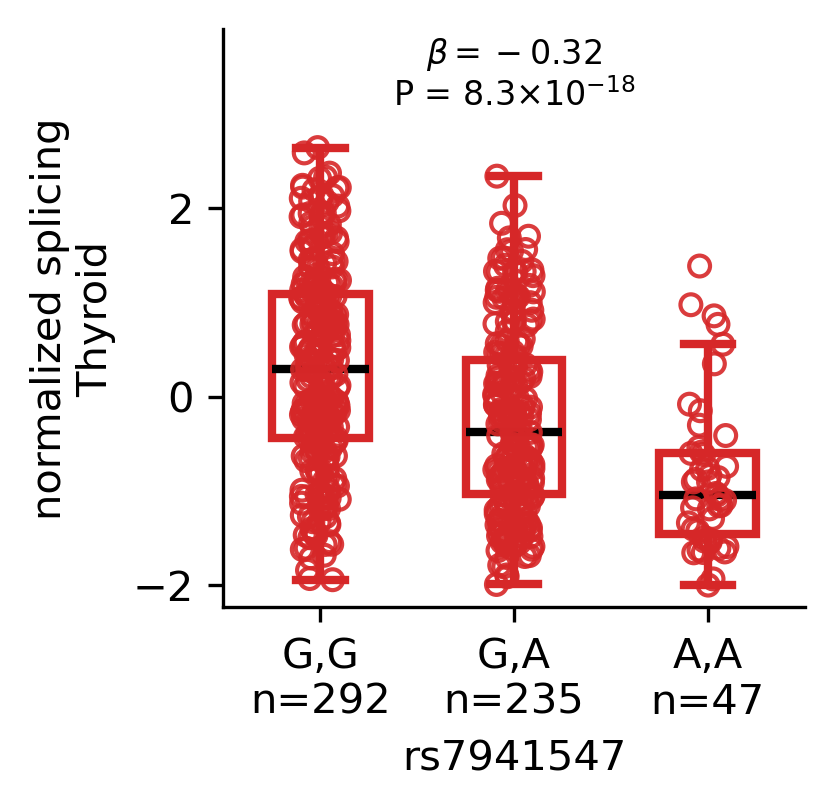

In [27]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:red')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

_b, _p = nominal_qtl_stats('Thyroid', 'leafcutter',
                           'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_sp.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_sp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_sp.svg', dpi=300, bbox_inches='tight') 

In [30]:
qqnorm_e.index = qqnorm_e.pid

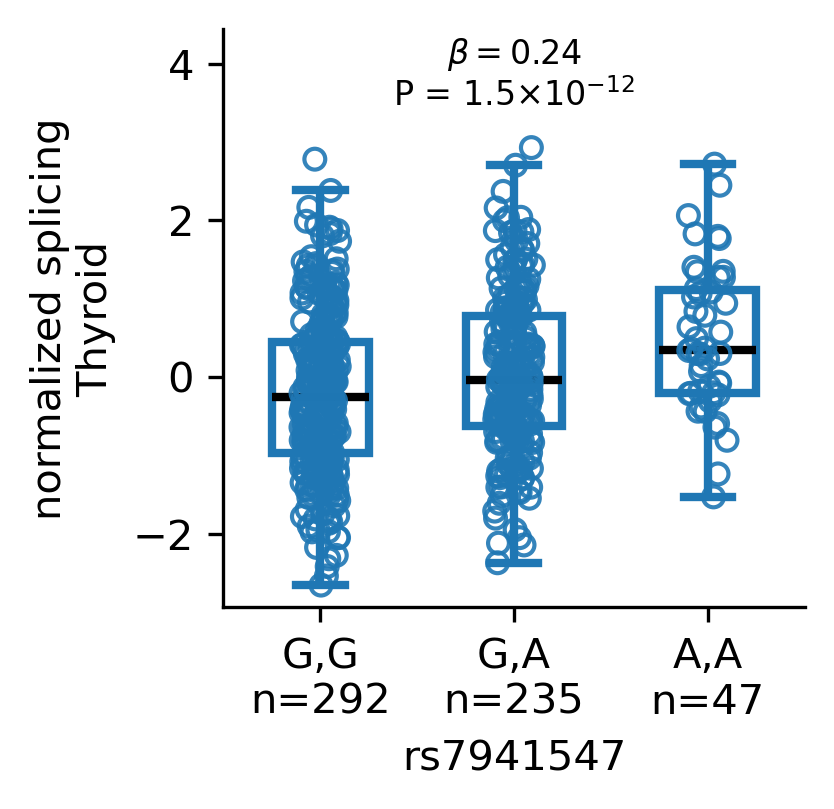

In [31]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0], color='tab:blue')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

_b, _p = nominal_qtl_stats('Thyroid', 'expression',
                           'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', 'chr11:611503')
if _b is not None:
    _yb, _yt = ax.get_ylim(); ax.set_ylim(_yb, _yt + 0.20 * (_yt - _yb))
    ax.text(0.5, 0.99, fmt_qtl(_b, _p), transform=ax.transAxes,
            ha='center', va='top', fontsize=8)

plt.savefig('plots/sup_hyperthyroid_exp.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_exp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_hyperthyroid_exp.svg', dpi=300, bbox_inches='tight') 

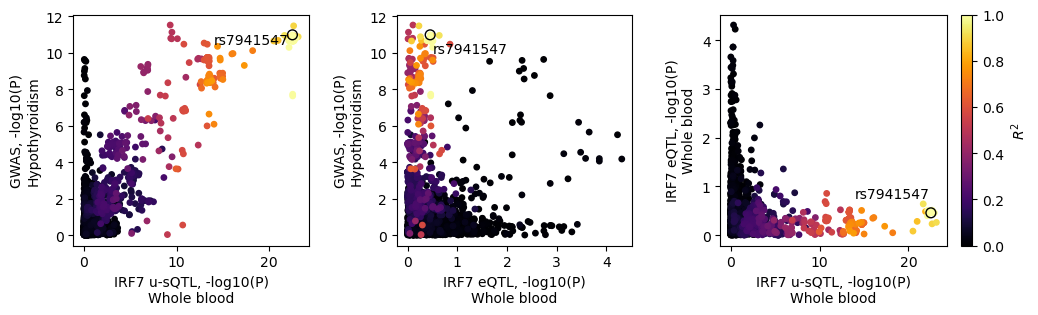

In [32]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_wb.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nWhole blood')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_wb.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(14, 10.5, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_wb_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[1].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nWhole blood')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_wb_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(0.5, 10, 'rs7941547')



x = -np.log10(np.array(nom_wb.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_wb_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[2].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nWhole blood')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nWhole blood')

x_r = -np.log10(np.array(nom_wb.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_wb_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(14, 0.75, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

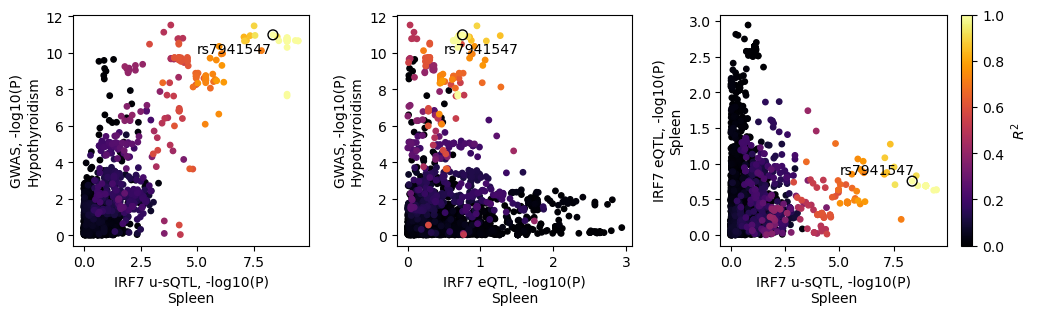

In [33]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_sp.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nSpleen')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_sp.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(5, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_sp_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[1].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nSpleen')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_sp_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(0.5, 10, 'rs7941547')



x = -np.log10(np.array(nom_sp.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_sp_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[2].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nSpleen')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nSpleen')

x_r = -np.log10(np.array(nom_sp.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_sp_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(5, 0.85, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [34]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_wb.index = qqnorm_wb.pid
qqnorm_lcl.index = qqnorm_lcl.pid

qqnorm_wb_e.index = qqnorm_wb_e.pid
qqnorm_lcl_e.index = qqnorm_lcl_e.pid

qqnorm_sp.index = qqnorm_sp.pid
qqnorm_sp_e.index = qqnorm_sp_e.pid

In [35]:
611503 - 614037

-2534

Text(0, 0.5, 'normalized splicing\nThyroid')

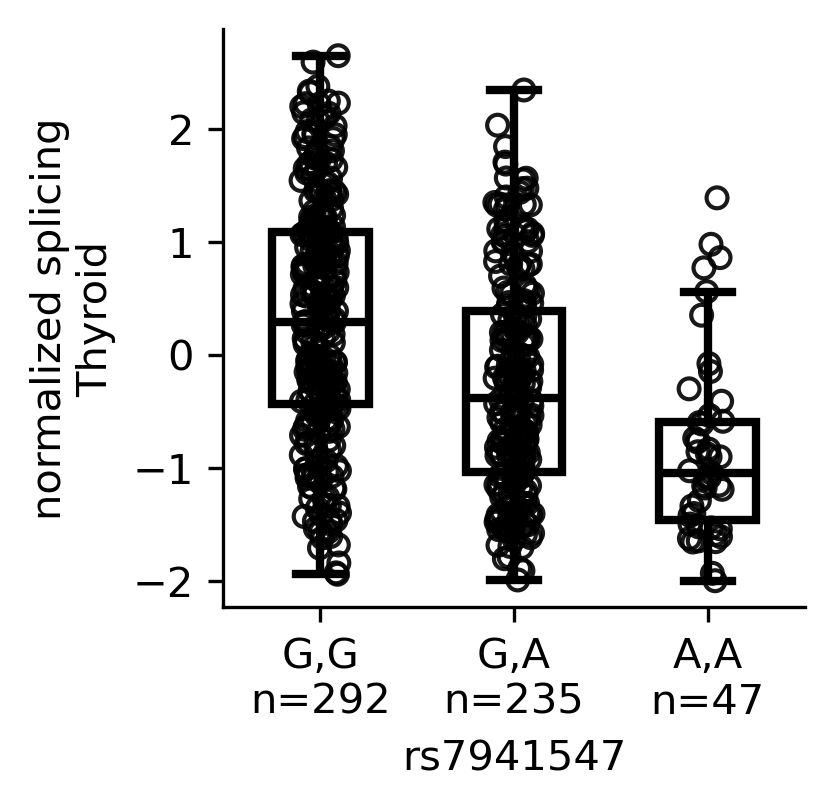

In [36]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

Text(0, 0.5, 'normalized splicing\nWhole blood')

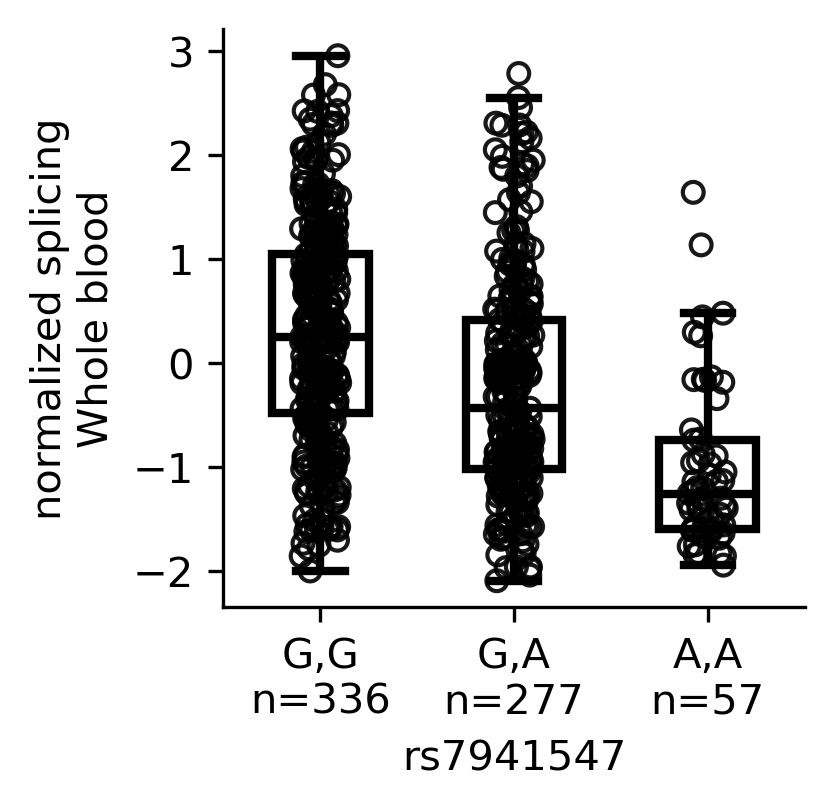

In [37]:
ax = make_boxplot_df(qqnorm_wb, 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nWhole blood')

Text(0, 0.5, 'normalized splicing\nLCLs')

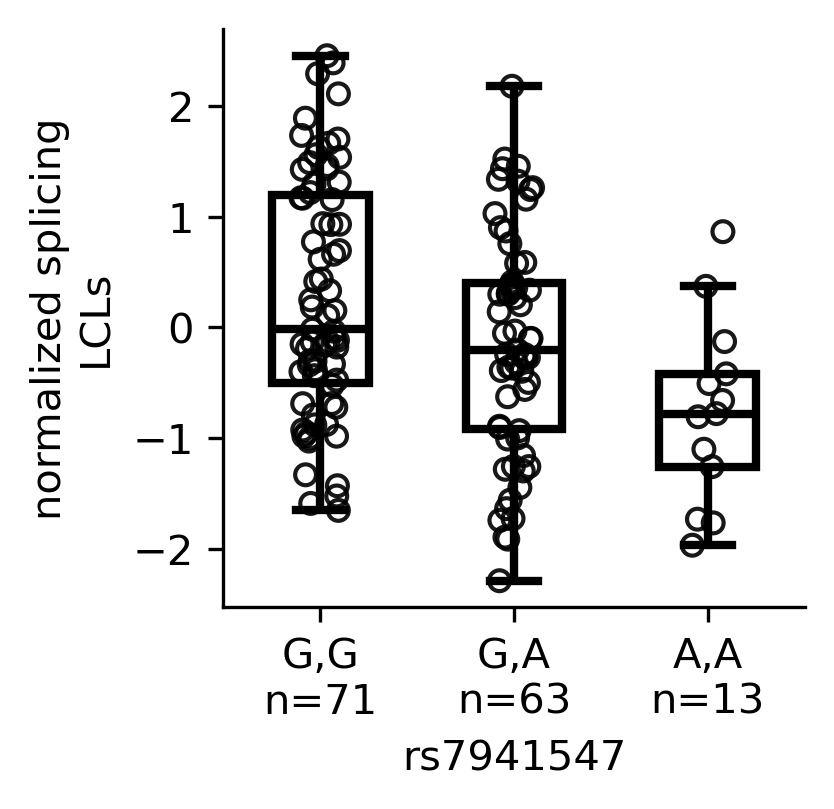

In [38]:
ax = make_boxplot_df(qqnorm_lcl, 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nLCLs')

Text(0, 0.5, 'normalized splicing\nSpleen')

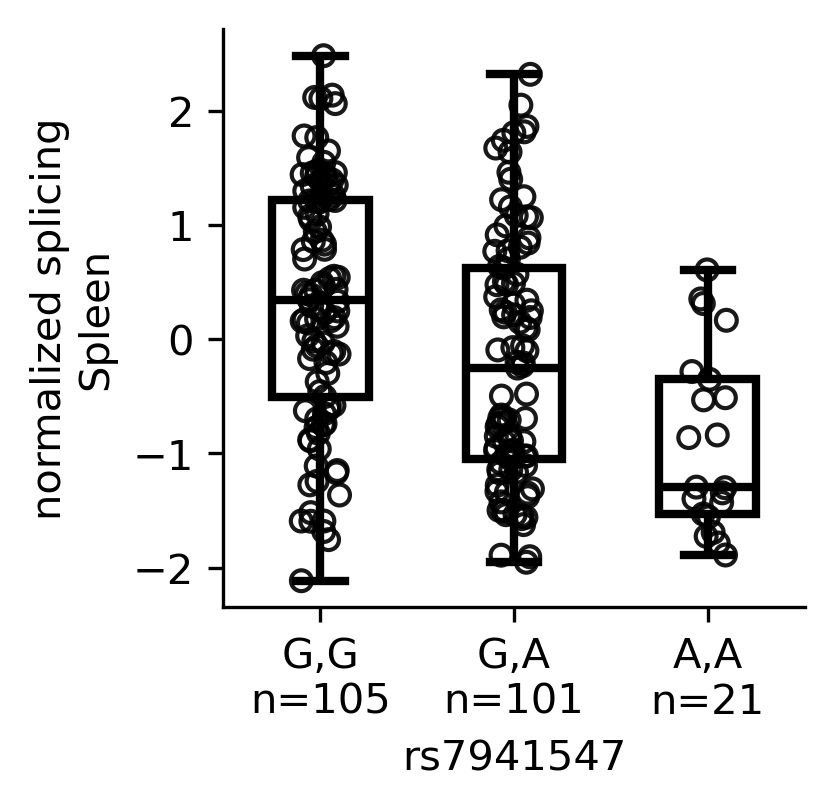

In [39]:
ax = make_boxplot_df(qqnorm_sp, 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nSpleen')

Text(0, 0.5, 'normalized expression\nSpleen')

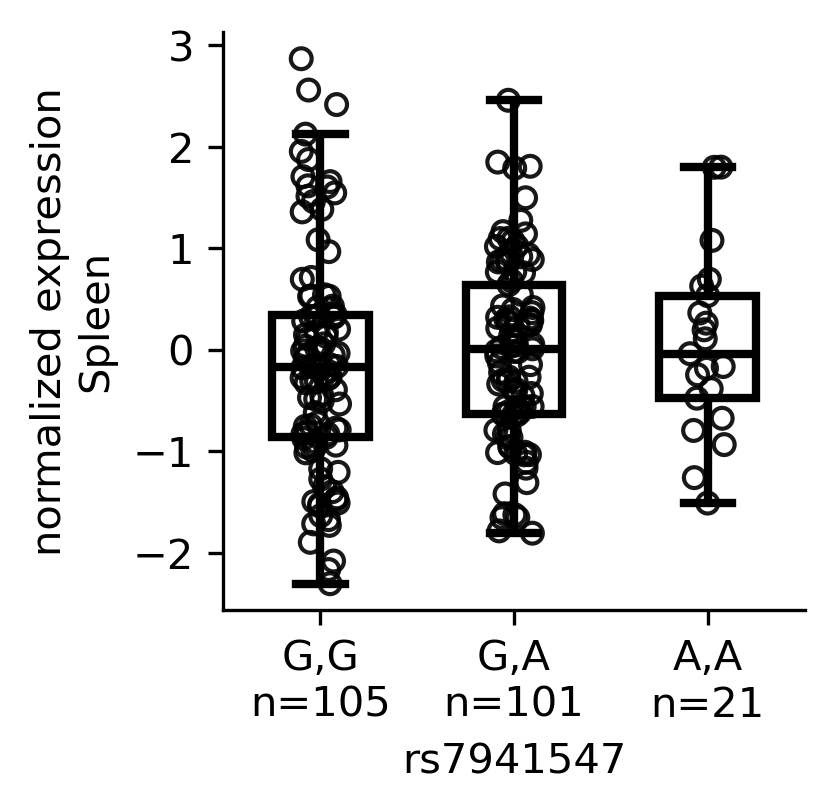

In [40]:
ax = make_boxplot_df(qqnorm_sp_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

Text(0, 0.5, 'normalized expression\nThyroid')

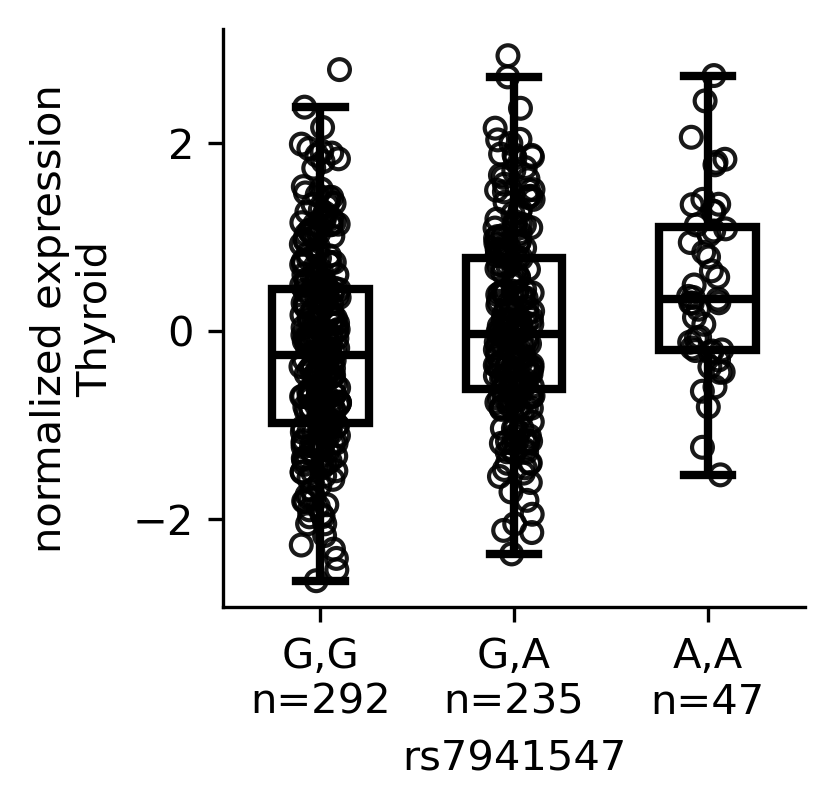

In [41]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nThyroid')

Text(0, 0.5, 'normalized expression\nWhole blood')

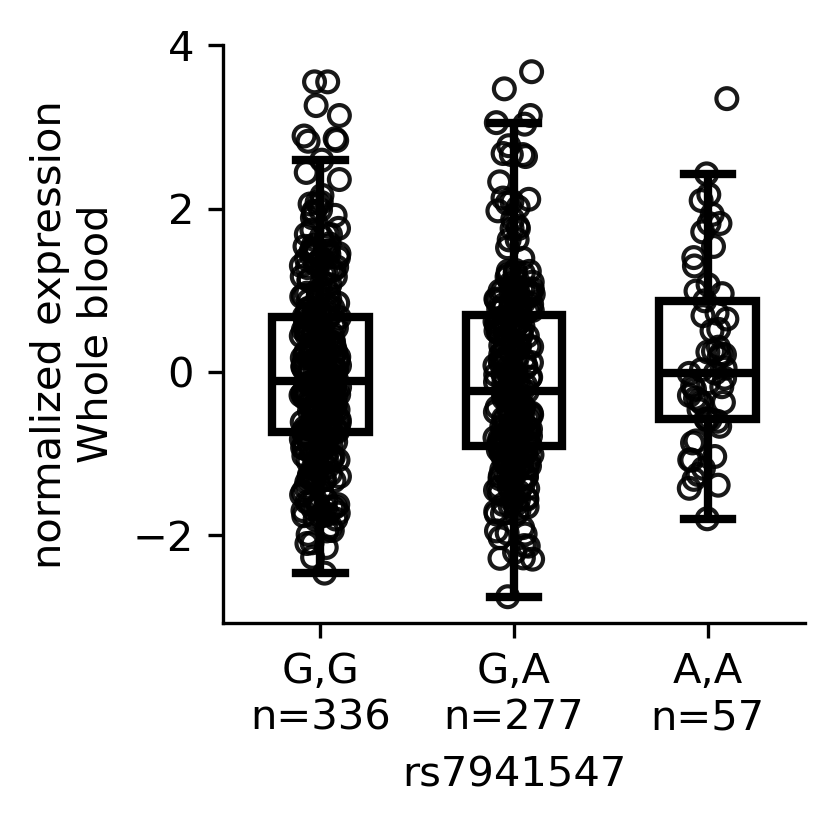

In [42]:
ax = make_boxplot_df(qqnorm_wb_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nWhole blood')

Text(0, 0.5, 'normalized expression\nLCLs')

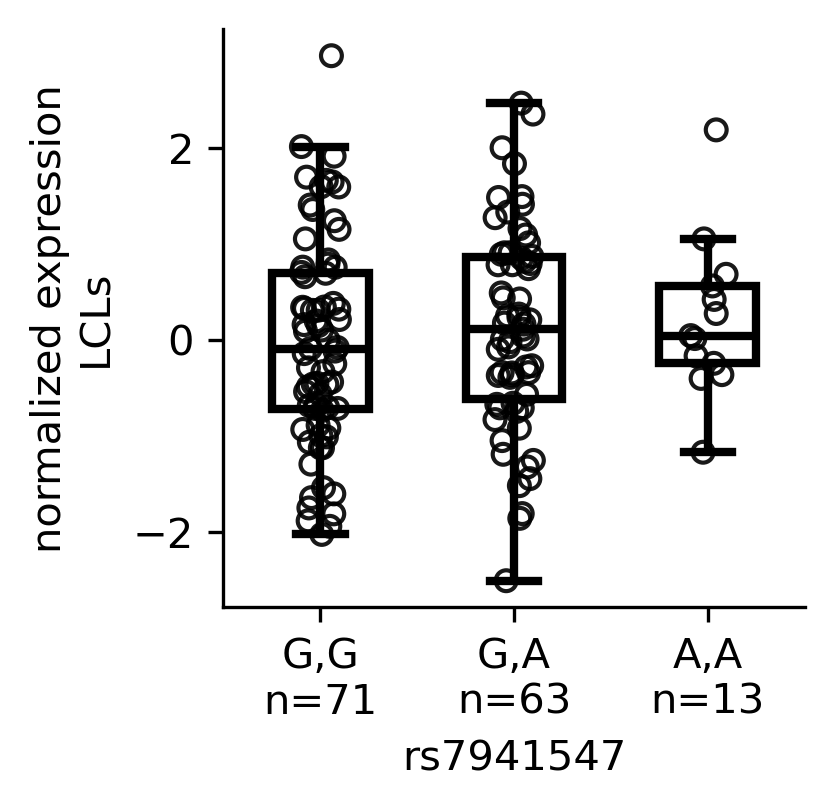

In [43]:
ax = make_boxplot_df(qqnorm_lcl_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nLCLs')

In [44]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-3000, 614475+3000)

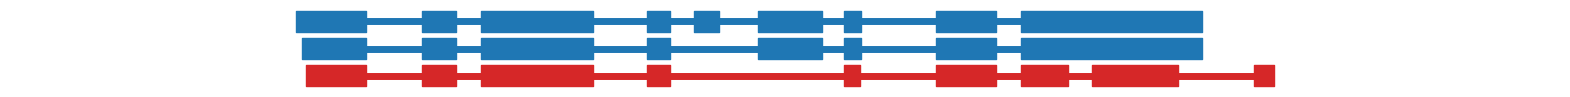

In [45]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000532326', 'ENST00000397570', 'ENST00000397566'])], 'ENSG00000185507', 
                         colores=['tab:blue', 'tab:blue', 'tab:red'], figsize=(20, 1), lwidth=5, iso_order=None)

In [46]:
hyprcoloc = pd.read_csv('../../code/results/coloc/hyprcoloc_results/tables/annotated_results.tsv.gz', 
                 sep='\t')

In [47]:
pheno = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Thyroid/separateNoise/leafcutter.qqnorm_chr11.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='pheno')
pheno['gid'] = pheno.pid.apply(lambda x: x.split(':')[3])

In [ ]:
# plot_isoform_annotations(aver.loc[aver.transcript_id.isin(['ENST00000589618', 'ENST00000293414'])], 'ENSG00000161664', 
#                          colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [ ]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr22', 41515917-3000, 41517296+3000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Cells-EBV-transformedlymphocytes/separateNoise/leafcutter.qqnorm_chr22.gz', 
          'chr22', 41515917-3000, 41517296+3000, file_type='pheno')

In [ ]:


plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000678394', 'ENST00000677554'])], 'ENSG00000100412', 
                         colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [ ]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr12', 57694926-3000, 57695779+3000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Cells-EBV-transformedlymphocytes/separateNoise/leafcutter.qqnorm_chr12.gz', 
          'chr12', 57694926-3000, 57695779+3000, file_type='pheno')
# clu_19636_+	

In [ ]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000552423', 'ENST00000389142'])], 'ENSG00000135506', 
                         colores=['tab:gray']*3, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [ ]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Multiple_sclerosis.standardized.txt.tabix.gz', 
          'chr12', 57694926-2000000, 57695779+2000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../../code/resources/gwas/raw_summary_statistics_new/IMSGC2019.unstandardized.sorted.txt.gz', 
          'chr12', 57694926-2000000, 57695779+2000000)

gwas_pval['snp_pos'] = gwas_pval.chrom + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Cells-EBV-transformedlymphocytes/leafcutter.NominalPass/chr12.txt.tabix.gz',
               'chr12', 57694926-2000000, 57695779+2000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Cells-EBV-transformedlymphocytes/expression.NominalPass/chr12.txt.tabix.gz',
               'chr12', 57694926-2000000, 57695779+2000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


In [ ]:
nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])

In [ ]:
nom.index = nom.snp_pos
nom_e.index = nom_e.snp_pos

In [ ]:
gwas_pval.index = gwas_pval.snp_pos
gwas.index = gwas.snp_pos

In [ ]:
plt.scatter(x, y)

In [ ]:
LD = pd.read_csv('../../code/results/coloc/LD/chr12_57713053_N_N_IMSGC2019.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)

In [ ]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float).mean(axis=1)))
y = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr12:57713053', snps_shared]
plt.scatter(x, y, c=r2)

In [ ]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float).mean(axis=1)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
plt.scatter(x, y, c=r2)

In [ ]:
import pysam
import pysam

def extract_genotypes(vcf_file, region):
    """
    Extract genotypes from a VCF file in a given region without using pyvcf.
    
    Parameters:
    - vcf_file (str): Path to the VCF file (must be bgzipped and indexed).
    - region (str): Region to query, formatted as 'chrom:start-end' (1-based).
    
    Returns:
    - genotypes (dict): Dictionary of variant positions and sample genotypes.
    """
    genotypes = {}
    
    # Open the VCF file using pysam
    with pysam.TabixFile(vcf_file) as tabix_file:
        try:
            # Fetch lines from the specified region
            region_lines = tabix_file.fetch(region=region)
            
            for line in region_lines:
                # Skip header lines
                if line.startswith("#"):
                    continue
                
                # Parse the VCF line
                fields = line.strip().split('\t')
                chrom, pos, _, _, _, _, _, info, format_field, *samples = fields
                
                # Extract genotype field index
                format_keys = format_field.split(':')
                try:
                    gt_index = format_keys.index('GT')
                except ValueError:
                    print(f"Genotype field 'GT' not found in format for variant at {pos}.")
                    continue
                
                # Extract genotypes for all samples
                sample_genotypes = [sample.split(':')[gt_index] for sample in samples]
                
                # Store genotypes with the position as the key
                genotypes[int(pos)] = sample_genotypes
        except ValueError:
            print(f"Region {region} not found in the VCF file.")
    
    return genotypes


# Example usage
vcf_file = "/project/yangili1/cfbuenabadn/SpliFi/code/results/geno/GTEx/Cells-EBV-transformedlymphocytes/chr12.vcf.gz"  # VCF file (bgzipped and indexed with tabix)
region = "chr12:56694926-58695779"  # Region to query

genotypes = extract_genotypes(vcf_file, region)

In [ ]:
for pos, sample_genotypes in genotypes.items():
    break

In [ ]:
import pysam
import numpy as np

def extract_genotypes_and_positions(vcf_file, region):
    """
    Extract genotypes and variant positions from a VCF file in a given region.

    Parameters:
    - vcf_file (str): Path to the VCF file (must be bgzipped and indexed).
    - region (str): Region to query, formatted as 'chrom:start-end' (1-based).

    Returns:
    - positions (list): List of variant positions.
    - genotype_matrix (numpy.ndarray): A matrix of genotypes (samples x variants).
    """
    positions = []
    genotypes = []

    with pysam.TabixFile(vcf_file) as tabix_file:
        try:
            region_lines = tabix_file.fetch(region=region)
            for line in region_lines:
                if line.startswith("#"):
                    continue

                # Parse the VCF line
                fields = line.strip().split('\t')
                pos = int(fields[1])
                format_field = fields[8]
                samples = fields[9:]

                # Extract genotype field
                format_keys = format_field.split(':')
                try:
                    gt_index = format_keys.index('GT')
                except ValueError:
                    print(f"Genotype field 'GT' not found in format for variant at {pos}.")
                    continue

                # Convert genotypes to numeric values (0, 1, 2, or NaN for missing)
                genotype_values = []
                for sample in samples:
                    gt = sample.split(':')[gt_index]
                    if gt == './.':
                        genotype_values.append(np.nan)
                    else:
                        alleles = gt.replace('|', '/').split('/')
                        genotype_values.append(sum(map(int, alleles)))

                positions.append(pos)
                genotypes.append(genotype_values)

        except ValueError:
            print(f"Region {region} not found in the VCF file.")

    genotype_matrix = np.array(genotypes).T  # Transpose to samples x variants
    return positions, genotype_matrix


def compute_ld_r2(genotype_matrix):
    """
    Compute the linkage disequilibrium (r2) between all pairs of variants.

    Parameters:
    - genotype_matrix (numpy.ndarray): A matrix of genotypes (samples x variants).

    Returns:
    - r2_matrix (numpy.ndarray): A symmetric matrix of r2 values (variants x variants).
    """
    # Standardize the genotype matrix (center and scale each column)
    standardized_matrix = (genotype_matrix - np.nanmean(genotype_matrix, axis=0)) / np.nanstd(genotype_matrix, axis=0)
    standardized_matrix = np.nan_to_num(standardized_matrix)  # Replace NaN with 0

    # Compute the correlation matrix
    correlation_matrix = np.corrcoef(standardized_matrix.T)

    # Square the correlation matrix to get r2 values
    r2_matrix = np.square(correlation_matrix)
    return r2_matrix


# Example usage
vcf_file = "/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz"  # VCF file (bgzipped and indexed with tabix)
region = "chr12:57214648-58212395"  # Region to query

positions, genotype_matrix = extract_genotypes_and_positions(vcf_file, region)
r2_matrix = compute_ld_r2(genotype_matrix)


In [ ]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_bm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_bm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

In [ ]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['#Chr'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_bm = run_tabix('../../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['#phe_id'].apply(lambda x: x.split(':')[-1])








In [ ]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['#phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb['#phe_id'] == 'chr11:802376:802542:clu_19976_-:UP:chr11_803017_N_N_GCST004988')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl['#phe_id'] == 'chr11:802376:802542:clu_18186_-:UP:chr11_803017_N_N_GCST004988')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_bm = nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm['#phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')]
nom_bm_e = nom_bm_e.loc[(nom_bm_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))#.intersection(pd.Index(nom_bm_e.snp_pos)).intersection(pd.Index(nom_bm.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

# nom_wb = nom_wb.groupby('snp_pos').first()
# nom_wb_e = nom_wb_e.groupby('snp_pos').first()

# nom_sp = nom_sp.groupby('snp_pos').first()
# nom_sp_e = nom_sp_e.groupby('snp_pos').first()

In [ ]:
LD = pd.read_csv('../../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



In [ ]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [ ]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_wb.index = qqnorm_wb.pid
qqnorm_lcl.index = qqnorm_lcl.pid

qqnorm_wb_e.index = qqnorm_wb_e.pid
qqnorm_lcl_e.index = qqnorm_lcl_e.pid

qqnorm_bm.index = qqnorm_bm.pid
qqnorm_bm_e.index = qqnorm_bm_e.pid

In [ ]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nPituitary')

In [ ]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm_bm, 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBreast mammary tissue')

In [ ]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

In [ ]:
ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nBreast mammary tissue')

In [ ]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-Cerebellum/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-Cerebellum/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')

qqnorm_bch = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_bch_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')


qqnorm_ms = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Muscle-Skeletal/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_ms_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Muscle-Skeletal/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')


In [ ]:
gwas = run_tabix('../../code/resources/gwas/StatsForColoc/Bipolar_disorder.standardized.txt.tabix.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/gwas/hg38_summary_stats/bipolar_disorder.bed.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../../code/results/coloc/qtls/Brain-Cerebellum/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../../code/results/coloc/qtls/Brain-Cerebellum/expression.NominalPass/chr17.txt.tabix.gz',
              'chr17', 44176940-1000000, 44177608+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_bch = run_tabix('../../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch['snp_pos'] = nom_bch.var_chr + ':' + nom_bch.var_from


nom_bch_e = run_tabix('../../code/results/coloc/qtls/Brain-CerebellarHemisphere/expression.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch_e['snp_pos'] = nom_bch_e.var_chr + ':' + nom_bch_e.var_from

nom_bch['gwas_trait'] = nom_bch['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_bch_e['gwas_trait'] = nom_bch_e['#phe_id'].apply(lambda x: x.split(':')[-1])



nom_ms = run_tabix('../../code/results/coloc/qtls/Muscle-Skeletal/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_ms['snp_pos'] = nom_ms.var_chr + ':' + nom_ms.var_from


nom_ms_e = run_tabix('../../code/results/coloc/qtls/Muscle-Skeletal/expression.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_ms_e['snp_pos'] = nom_ms_e.var_chr + ':' + nom_ms_e.var_from

nom_ms['gwas_trait'] = nom_ms['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_ms_e['gwas_trait'] = nom_ms_e['#phe_id'].apply(lambda x: x.split(':')[-1])






In [ ]:
nom = nom.loc[(nom.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom['#phe_id'] == 'chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]

nom_bch = nom_bch.loc[(nom_bch.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch['#phe_id'] == 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_bch_e = nom_bch_e.loc[(nom_bch_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]


nom_ms = nom_ms.loc[(nom_ms.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_ms['#phe_id'] == 'chr17:44176940:44177608:clu_30815_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_ms_e = nom_ms_e.loc[(nom_ms_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_ms_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]




snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos)).intersection(pd.Index(nom_bch_e.snp_pos)).intersection(pd.Index(nom_bch.snp_pos)).intersection(pd.Index(nom_ms_e.snp_pos)).intersection(pd.Index(nom_ms.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

nom_bch = nom_bch.groupby('snp_pos').first()
nom_bch_e = nom_bch_e.groupby('snp_pos').first()

nom_ms = nom_ms.groupby('snp_pos').first()
nom_ms_e = nom_ms_e.groupby('snp_pos').first()

In [ ]:
LD = pd.read_csv('../../code/results/coloc/LD/chr17_44114525_N_N_bipolar_disorder.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



In [ ]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [ ]:
# NOTE: this cell also builds a MAIN figure (fig4_coloc_example), which is reproduced
# properly in ../Figure2/ or ../Figure4/. Its savefig calls are disabled.
# The rest of the cell is left intact because it defines `scatter_df`, used later.
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2], dpi=300)
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[0].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(7, 7.5, 'rs7212573')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[1].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(4.5, 7.5, 'rs7212573')



x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[2].set_ylabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')

x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(7, 6.5, 'rs7212573')

ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[2].spines[['top', 'right']].set_visible(False)

fig.subplots_adjust(wspace=0.35, hspace=5)

# [main figure -- disabled] # plt.savefig('plots/fig4_coloc_example.png', dpi=300, bbox_inches='tight')
# [main figure -- disabled] # plt.savefig('plots/fig4_coloc_example.pdf', dpi=300, bbox_inches='tight')
# [main figure -- disabled] # plt.savefig('plots/fig4_coloc_example.svg', dpi=300, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_ms.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_ms.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_ms_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_ms_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom_ms.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_ms_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom_ms.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_ms_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [ ]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_bch.index = qqnorm_bch.pid
qqnorm_bch_e.index = qqnorm_bch_e.pid

qqnorm_ms.index = qqnorm_ms.pid
qqnorm_ms_e.index = qqnorm_ms_e.pid

In [ ]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm, 'chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('normalized splicing\nBrain Cerebellum')


In [ ]:
from scipy.stats import t

# Given values
slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)
n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error


In [ ]:
   
def make_boxplot_df_colored(qqnorm_data, phenotype, record, phenotype_class='', color='black'):
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    # if color_by_phenotype:
    #     colores = [color_by_phenotype]*3

    # else:
    #     colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.8, showfliers=False,
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor=color),
           whiskerprops = dict(color=color),
           capprops = dict(color=color),
           medianprops = dict(linewidth=2, color='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.9, edgecolor=color, facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    # n per genotype, under each tick -- same convention as Fig. 4e
    counts = df.genotype.value_counts()
    order = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{g}\nn={counts[g]}' for g in order])

    return ax

In [ ]:
# NOTE: this cell also builds a MAIN figure (fig4_coloc_example_sQTL), which is reproduced
# properly in ../Figure2/ or ../Figure4/. Its savefig calls are disabled.
# The rest of the cell is left intact because it defines `confidence_level`, `intercept`, `lower_bound`, `margin_of_error`, `records`, `slope`, `slope_10`, `slope_90`, `slope_se`, `t_crit`, `upper_bound`, used later.
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm_bch, 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

ax.plot(x, slope * x + intercept, color='red', linestyle='--')


ax.text(1.5, 1, r'$\beta = -0.62$' + '\np-val $< 1e-10$')


# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL.png', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL.pdf', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL.svg', dpi=300, bbox_inches='tight')

In [ ]:
# NOTE: this cell also builds a MAIN figure (fig4_coloc_example_sQTL_colored), which is reproduced
# properly in ../Figure2/ or ../Figure4/. Its savefig calls are disabled.
# The rest of the cell is left intact because it defines `confidence_level`, `intercept`, `lower_bound`, `margin_of_error`, `records`, `slope`, `slope_10`, `slope_90`, `slope_se`, `t_crit`, `upper_bound`, used later.
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df_colored(qqnorm_bch, 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0], color='tab:red')
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0.62
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

# ax.plot(x, slope * x + intercept, color='red', linestyle='--')


ax.text(1.5, 1, r'$\beta = -0.62$' + '\np-val $< 1e-10$')


# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL_colored.png', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL_colored.pdf', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_sQTL_colored.svg', dpi=300, bbox_inches='tight')

In [ ]:
np.linspace(0, 2, 100)

In [ ]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm_ms, 'chr17:44176940:44177608:clu_30815_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBrain Cerebellum')

In [ ]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

In [ ]:
# NOTE: this cell also builds a MAIN figure (fig4_coloc_example_eQTL), which is reproduced
# properly in ../Figure2/ or ../Figure4/. Its savefig calls are disabled.
# The rest of the cell is left intact because it defines `confidence_level`, `intercept`, `lower_bound`, `margin_of_error`, `slope`, `slope_10`, `slope_90`, `slope_se`, `t_crit`, `upper_bound`, used later.
ax = make_boxplot_df_colored(qqnorm_bch_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch_e.loc['chr17:44176913'].slope)
slope_se = float(nom_bch_e.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

ax.plot(x, slope * x + intercept, color='red', linestyle='--')


ax.text(1.5, -2.8, r'$\beta = 0.25$' + '\np-val $< 1e-7$')



# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL.png', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL.pdf', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL.svg', dpi=300, bbox_inches='tight')

In [ ]:
# NOTE: this cell also builds a MAIN figure (fig4_coloc_example_eQTL_colored), which is reproduced
# properly in ../Figure2/ or ../Figure4/. Its savefig calls are disabled.
# The rest of the cell is left intact because later cells build on the objects it leaves behind.
ax = make_boxplot_df_colored(qqnorm_bch_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0], color='tab:blue')
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch_e.loc['chr17:44176913'].slope)
slope_se = float(nom_bch_e.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

# ax.plot(x, slope * x + intercept, color='red', linestyle='--')


ax.text(1.5, -2.8, r'$\beta = 0.25$' + '\np-val $< 1e-7$')



# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL_colored.png', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL_colored.pdf', dpi=300, bbox_inches='tight')
# [main figure -- disabled] plt.savefig('plots/fig4_coloc_example_eQTL_colored.svg', dpi=300, bbox_inches='tight')

In [ ]:
ax = make_boxplot_df(qqnorm_ms_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

In [ ]:
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')


In [ ]:
pos = [int(x.split(':')[1]) for x in scatter_df.index]
plt.scatter(pos, np.array(scatter_df.sQTL), c=scatter_df.r2)

In [ ]:
# ===== MAIN FIGURE CELL -- COMMENTED OUT =====
# Builds fig4_ASB16, which is a main figure reproduced
# properly in ../Figure2/ or ../Figure4/. Nothing later in this notebook
# uses what it defines, so it is disabled here.
# plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000293414', 'ENST00000589618'])], 'ENSG00000161664',
#                          colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)
#
# plt.savefig('plots/fig4_ASB16.png', dpi=300, bbox_inches='tight')
# plt.savefig('plots/fig4_ASB16.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('plots/fig4_ASB16.svg', dpi=300, bbox_inches='tight')